# 03 — Mode-Candidate Beam Optimizer for Pulsar Distance Recovery

Cleaner notebook for efficient multi-CW distance recovery.

Core idea:

1. Inject CW dataset using hidden pulsar distances drawn from EM priors.
2. Generate robust per-pulsar distance-mode candidates from several conditioning contexts.
3. Keep a beam of full-array distance hypotheses.
4. For each pulsar pair, scan local 2D patches around candidate modes and current beam values.
5. Keep top beam states and iterate.

This is deterministic brute-force optimization in mode space, not MCMC.

In [1]:
from pathlib import Path
import sys
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

HERE = Path.cwd()
sys.path.insert(0, str((HERE / "../CW_lnL_check").resolve()))

from cw_helpers import (
    build_disco_likelihood,
    build_enterprise_pta,
    build_pure_cw_likelihood,
    compute_mode_spacing,
    generate_injection_params,
    inject_noisefree_cw,
    load_pulsars,
    scan_pulsar_distance,
    scan_pulsar_pair_2d,
    simulate,
)

print(HERE)

/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


/home/mattm/projects/HSYMT/lnL_distance_scans


## Control Panel

In [2]:
# Dataset knobs
DATA_MODE = "pure"            # "pure" or "stochastic"
N_PSR = 20                    # use <=80 with discovery HD GWB
N_CW = 4
LOG10_H = -12.0
LOG10_MC = None
RNG_SEED = 12345
NOISE_SEED = 24680

# Truth-vs-prior split
TRUTH_DISTANCE_MODE = "gaussian_prior_draw"  # "prior_mean", "gaussian_prior_draw", "sigma_offset"
TRUTH_SIGMA_OFFSET = 1.0
TRUTH_SIGMA_CLIP = 3.0

# Stochastic mode knobs
STOCHASTIC_SCENARIO = "well_separated"
COMPONENTS = 10
INCLUDE_GWB = True
GWB_LOG10_A = -17.5
GWB_GAMMA = 13/3

# Pair ordering
PAIR_MODE = "anchor_ladder"   # "anchor", "anchor_ladder", "all"
MAX_PAIRS_PER_SWEEP = 0       # 0 = full chosen schedule

# Robust candidate generation. Increase these only if candidate truth coverage is poor.
MODE_PRIOR_SIGMA_WIDTH = 3.0
MODE_SAMPLES_PER_MODE = 4
MAX_1D_SCAN_POINTS = 3000
TOP_MODE_CANDIDATES = 30
N_CONTEXT_RANDOM = 3          # extra conditioning contexts for 1D candidate scans
CONTEXT_SIGMA_CLIP = 3.0

# Beam optimizer. Fast defaults use two-stage pair scan: candidate centers -> tiny local refinement.
BEAM_WIDTH = 12
ELITE_BEAM_WIDTH = 4             # always keep top lnL states
DIVERSE_BEAM_WIDTH = 8           # also keep mode-diverse states, even if lower lnL
ACTIVE_BEAM_WIDTH_PER_PAIR = 12    # scan only top active states each pair; carry rest forward unchanged
BEAM_RANDOM_STATES = 64          # random combinations of candidate modes
RAW_PRIOR_RANDOM_STATES = 16       # raw Gaussian-prior starts, same distribution family as truth
PAIR_CENTER_K = 6                 # candidate centers per pulsar for coarse pair center scan
PAIR_REFINE_TOP_N = 4             # refine this many center-scan peaks
PAIR_PROPOSALS_PER_STATE = 4        # keep this many pair-update proposals per active state             # local refinement patches around top center-scan peaks
PAIR_LOCAL_HALF_WIDTH_MODES = 0.75
PAIR_LOCAL_POINTS_PER_MODE = 2
PAIR_LOCAL_MIN_POINTS = 5
BEAM_MAX_SWEEPS = 2
FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG = False # keep False for real optimizer; diagnostics force truth separately
CHUNK_SIZE = None

# Display / progress
PLOT_DURING_RUN = False
PLOT_EVERY_PAIR = 10
PROGRESS_EVERY_PAIR = 1
KEEP_PAIR_RECORDS = 20

## Helpers

In [3]:
CW_LIBRARY = [
    dict(cos_gwtheta=0.30, gwphi=2.50, cos_inc=-0.20, phase0=1.00, psi=0.70, log10_h=-12.0, log10_mc=9.00, log10_fgw=-8.00),
    dict(cos_gwtheta=-0.50, gwphi=0.80, cos_inc=0.40, phase0=2.10, psi=1.30, log10_h=-12.0, log10_mc=9.00, log10_fgw=-7.80),
    dict(cos_gwtheta=0.05, gwphi=4.20, cos_inc=-0.65, phase0=0.35, psi=2.30, log10_h=-12.0, log10_mc=9.00, log10_fgw=-8.20),
    dict(cos_gwtheta=0.70, gwphi=5.40, cos_inc=0.10, phase0=1.70, psi=0.20, log10_h=-12.0, log10_mc=9.00, log10_fgw=-7.90),
    dict(cos_gwtheta=-0.10, gwphi=3.30, cos_inc=0.80, phase0=2.90, psi=1.80, log10_h=-12.0, log10_mc=9.00, log10_fgw=-8.10),
]


def clipped_normal(mean, sigma, rng, clip):
    draw = rng.normal(mean, sigma)
    lo = np.maximum(0.01, mean - clip * sigma)
    hi = mean + clip * sigma
    return np.clip(draw, lo, hi)


def select_pulsars(n_psr):
    ent_all, disco_all = load_pulsars(None)
    pairs = sorted(zip(ent_all, disco_all), key=lambda pair: pair[1].pdist[1])
    selected = pairs[:n_psr]
    return [p[0] for p in selected], [p[1] for p in selected], len(disco_all)


def clone_psrs_with_distances(psrs, distances):
    clones = copy.deepcopy(psrs)
    for psr, dist in zip(clones, distances):
        sigma = float(psr.pdist[1])
        try:
            psr.pdist = (float(dist), sigma)
        except Exception:
            psr._pdist = (float(dist), sigma)
    return clones


def make_truth_distances(prior_mean, prior_sigma, rng):
    if TRUTH_DISTANCE_MODE == "prior_mean":
        return prior_mean.copy()
    if TRUTH_DISTANCE_MODE == "gaussian_prior_draw":
        return clipped_normal(prior_mean, prior_sigma, rng, TRUTH_SIGMA_CLIP)
    if TRUTH_DISTANCE_MODE == "sigma_offset":
        signs = rng.choice([-1.0, 1.0], size=len(prior_mean))
        return np.maximum(0.01, prior_mean + signs * TRUTH_SIGMA_OFFSET * prior_sigma)
    raise ValueError(TRUTH_DISTANCE_MODE)


def cw_params_from_library(n_cw, log10_h=None, log10_mc=None):
    if n_cw > len(CW_LIBRARY):
        raise ValueError(f"N_CW={n_cw} exceeds CW_LIBRARY size={len(CW_LIBRARY)}")
    out = [dict(cw) for cw in CW_LIBRARY[:n_cw]]
    for cw in out:
        if log10_h is not None:
            cw["log10_h"] = log10_h
        if log10_mc is not None:
            cw["log10_mc"] = log10_mc
    return out


def cw_list_from_enterprise_params(enterprise_params, cw_block_names):
    keys = ("cos_gwtheta", "gwphi", "cos_inc", "log10_mc", "log10_fgw", "log10_h", "phase0", "psi")
    return [{key: float(enterprise_params[f"{name}_{key}"]) for key in keys} for name in cw_block_names]


def make_pair_schedule(n_psr, mode):
    if mode == "all":
        pairs = [(i, j) for i in range(n_psr) for j in range(i + 1, n_psr)]
    elif mode == "anchor":
        pairs = [(0, j) for j in range(1, n_psr)]
    elif mode == "anchor_ladder":
        pairs = [(0, j) for j in range(1, n_psr)]
        pairs += [(j, j + 1) for j in range(1, n_psr - 1)]
        pairs = list(dict.fromkeys(pairs))
    else:
        raise ValueError(mode)
    return pairs[:MAX_PAIRS_PER_SWEEP] if MAX_PAIRS_PER_SWEEP else pairs


def distance_key(psr):
    return f"{psr.name}_cw_p_dist"


def set_distances(values, param_keys, disco_psrs, distances):
    out = np.array(values, dtype=float).copy()
    for psr, dist in zip(disco_psrs, distances):
        out[param_keys.index(distance_key(psr))] = dist
    return out


def get_distances(values, param_keys, disco_psrs):
    return np.array([float(values[param_keys.index(distance_key(psr))]) for psr in disco_psrs])


def min_mode_spacings(disco_psrs, cw_params_list):
    out = []
    for psr in disco_psrs:
        vals = [compute_mode_spacing(cw["cos_gwtheta"], cw["gwphi"], cw["log10_fgw"], psr.pos) for cw in cw_params_list]
        out.append(float(np.nanmin(vals)))
    return np.array(out)


def recovery_score(distances):
    err = distances - truth_dist
    em = err / mode_spacings
    es = err / sigmas
    return dict(
        frac_within_half_mode=float(np.mean(np.abs(em) < 0.5)),
        frac_within_one_mode=float(np.mean(np.abs(em) < 1.0)),
        median_abs_modes=float(np.median(np.abs(em))),
        max_abs_modes=float(np.max(np.abs(em))),
        median_abs_sigma=float(np.median(np.abs(es))),
        max_abs_sigma=float(np.max(np.abs(es))),
    )


def top_local_maxima(x, y, k):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)
    x, y = x[finite], y[finite]
    if len(x) == 0:
        return np.array([]), np.array([])
    if len(x) >= 3:
        idx = np.where(np.r_[False, (y[1:-1] >= y[:-2]) & (y[1:-1] >= y[2:]), False])[0]
    else:
        idx = np.array([], dtype=int)
    if len(idx) < k:
        idx = np.unique(np.r_[idx, np.argsort(y)[::-1]])
    idx = idx[np.argsort(y[idx])[::-1]][:k]
    return x[idx], y[idx]


def candidate_grid_bounds(i):
    lo = max(0.01, prior_mean[i] - MODE_PRIOR_SIGMA_WIDTH * sigmas[i])
    hi = prior_mean[i] + MODE_PRIOR_SIGMA_WIDTH * sigmas[i]
    dL = mode_spacings[i]
    if not np.isfinite(dL) or dL <= 0:
        n_points = MAX_1D_SCAN_POINTS
    else:
        n_points = int(np.ceil((hi - lo) / dL * MODE_SAMPLES_PER_MODE)) + 1
        n_points = int(np.clip(n_points, 25, MAX_1D_SCAN_POINTS))
    return lo, hi, n_points


def local_grid_around_centers(centers, i):
    lo, hi, _ = candidate_grid_bounds(i)
    dL = mode_spacings[i]
    centers = np.asarray(centers, dtype=float)
    centers = centers[np.isfinite(centers)]
    if len(centers) == 0:
        return np.linspace(lo, hi, PAIR_LOCAL_MIN_POINTS)
    half = PAIR_LOCAL_HALF_WIDTH_MODES * dL if np.isfinite(dL) and dL > 0 else 0.1 * (hi - lo)
    n = int(max(PAIR_LOCAL_MIN_POINTS, np.ceil(2 * PAIR_LOCAL_HALF_WIDTH_MODES * PAIR_LOCAL_POINTS_PER_MODE + 1)))
    pieces = []
    for c in centers:
        a = max(lo, c - half)
        b = min(hi, c + half)
        pieces.append(np.linspace(a, b, n) if b > a else np.array([np.clip(c, lo, hi)]))
    return np.unique(np.concatenate(pieces))


def dedupe_beam(states, max_states):
    seen = set()
    out = []
    for st in sorted(states, key=lambda s: s["lnL"], reverse=True):
        key = tuple(np.round(st["distances"] / mode_spacings, 2))
        if key in seen:
            continue
        seen.add(key)
        out.append(st)
        if len(out) >= max_states:
            break
    return out


def nearest_grid_value(grid, x):
    grid = np.asarray(grid, dtype=float)
    idx = int(np.nanargmin(np.abs(grid - x)))
    return idx, float(grid[idx])


def draw_truth_crosshair(ax, truth_i, truth_j):
    ax.axvline(truth_j, color="black", lw=3.0, ls="--", alpha=0.9, zorder=8)
    ax.axhline(truth_i, color="black", lw=3.0, ls="--", alpha=0.9, zorder=8)
    ax.axvline(truth_j, color="magenta", lw=1.6, ls="--", alpha=0.95, zorder=9, label="truth")
    ax.axhline(truth_i, color="magenta", lw=1.6, ls="--", alpha=0.95, zorder=9)


def set_pair_plot_limits(ax, grid_i, grid_j, truth_i, truth_j, pad_frac=0.05):
    xvals = np.asarray(list(grid_j) + [truth_j], dtype=float)
    yvals = np.asarray(list(grid_i) + [truth_i], dtype=float)
    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals), np.nanmax(yvals)
    ax.set_xlim(xmin - max((xmax - xmin) * pad_frac, 1e-9), xmax + max((xmax - xmin) * pad_frac, 1e-9))
    ax.set_ylim(ymin - max((ymax - ymin) * pad_frac, 1e-9), ymax + max((ymax - ymin) * pad_frac, 1e-9))


def unique_sorted(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    return np.unique(vals)


def center_values_for_pulsar(state, i):
    vals = [state["distances"][i], prior_mean[i]]
    vals += list(mode_candidates[i]["distances"][:PAIR_CENTER_K])
    if FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG:
        vals.append(truth_dist[i])
    lo, hi, _ = candidate_grid_bounds(i)
    vals = np.clip(vals, lo, hi)
    return unique_sorted(vals)


def local_grid_single(center, i):
    lo, hi, _ = candidate_grid_bounds(i)
    dL = mode_spacings[i]
    half = PAIR_LOCAL_HALF_WIDTH_MODES * dL if np.isfinite(dL) and dL > 0 else 0.02 * (hi - lo)
    n = int(max(PAIR_LOCAL_MIN_POINTS, np.ceil(2 * PAIR_LOCAL_HALF_WIDTH_MODES * PAIR_LOCAL_POINTS_PER_MODE + 1)))
    a = max(lo, center - half)
    b = min(hi, center + half)
    grid = np.linspace(a, b, n) if b > a else np.array([np.clip(center, lo, hi)])
    if FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG:
        grid = np.unique(np.r_[grid, truth_dist[i]])
    return grid


def top_surface_indices(surf, n):
    flat = np.asarray(surf).ravel()
    finite = np.where(np.isfinite(flat))[0]
    if len(finite) == 0:
        return []
    order = finite[np.argsort(flat[finite])[::-1]]
    out = []
    seen = set()
    for idx in order:
        ij = np.unravel_index(idx, surf.shape)
        if ij in seen:
            continue
        seen.add(ij)
        out.append(ij)
        if len(out) >= n:
            break
    return out


def mode_vector(distances):
    return np.asarray(distances, dtype=float) / mode_spacings


def select_diverse_beam(states, max_states=None):
    """Keep high-lnL states plus mode-diverse lower-lnL states.

    Pure lnL pruning can kill intermediate states needed to cross between
    multimodal basins. This selection keeps elites, then greedily adds states
    far from already-kept states in mode-index space.
    """
    max_states = BEAM_WIDTH if max_states is None else max_states
    sorted_states = sorted(states, key=lambda s: s["lnL"], reverse=True)
    deduped = []
    seen = set()
    for st in sorted_states:
        key = tuple(np.round(mode_vector(st["distances"]), 2))
        if key in seen:
            continue
        seen.add(key)
        deduped.append(st)

    kept = deduped[:min(ELITE_BEAM_WIDTH, max_states)]
    remaining = deduped[min(ELITE_BEAM_WIDTH, max_states):]
    while remaining and len(kept) < max_states:
        kept_vecs = np.array([mode_vector(st["distances"]) for st in kept])
        best_idx = None
        best_score = -np.inf
        for idx, st in enumerate(remaining):
            v = mode_vector(st["distances"])
            dist = np.min(np.sqrt(np.mean((kept_vecs - v[None, :]) ** 2, axis=1)))
            # mostly diversity, slight lnL tie-breaker after scaling.
            score = dist + 1e-6 * (st["lnL"] - deduped[0]["lnL"])
            if score > best_score:
                best_score = score
                best_idx = idx
        kept.append(remaining.pop(best_idx))
    return kept


def mutate_beam_state(state, n_mutations=2):
    """Randomly replace a few pulsars by candidate modes to seed bridge states."""
    d = state["distances"].copy()
    idxs = rng.choice(np.arange(len(disco_psrs)), size=min(n_mutations, len(d)), replace=False)
    for i in idxs:
        c = mode_candidates[i]
        if len(c["distances"]):
            # use flatter distribution than candidate init
            d[i] = rng.choice(c["distances"])
    vals = set_distances(base_values, param_keys, disco_psrs, d)
    return dict(label=f"mutated_{state.get('label', 'beam')}", distances=d, values=vals, lnL=float(logl_fn(vals)))


## Build Injection and Likelihood

In [4]:
rng = np.random.default_rng(RNG_SEED)
np.random.seed(NOISE_SEED)

t0 = time.time()
ent_psrs, disco_psrs, total_loaded = select_pulsars(N_PSR)
prior_mean = np.array([p.pdist[0] for p in disco_psrs], dtype=float)
sigmas = np.array([p.pdist[1] for p in disco_psrs], dtype=float)
truth_dist = make_truth_distances(prior_mean, sigmas, rng)

ent_psrs_inj = clone_psrs_with_distances(ent_psrs, truth_dist)
disco_psrs_inj = clone_psrs_with_distances(disco_psrs, truth_dist)

if DATA_MODE == "pure":
    cw_params_list = cw_params_from_library(N_CW, LOG10_H, LOG10_MC)
    residual_map, _ = inject_noisefree_cw(disco_psrs_inj, cw_params_list)
    logl_fn, param_keys, base_values = build_pure_cw_likelihood(disco_psrs, residual_map, cw_params_list)
    enterprise_params = None
    cw_block_names = None
else:
    pta, cw_block_names, _ = build_enterprise_pta(ent_psrs_inj, N_CW, components=COMPONENTS)
    enterprise_params = generate_injection_params(
        pta, ent_psrs_inj, N_CW, cw_block_names,
        log10_h=LOG10_H,
        scenario=STOCHASTIC_SCENARIO,
        rng=rng,
        gwb_log10_A=GWB_LOG10_A,
        gwb_gamma=GWB_GAMMA,
    )
    if LOG10_MC is not None:
        for name in cw_block_names:
            enterprise_params[f"{name}_log10_mc"] = LOG10_MC
    cw_params_list = cw_list_from_enterprise_params(enterprise_params, cw_block_names)
    sim_resids = simulate(pta, enterprise_params, sparse_cholesky=True)
    residual_map = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}
    logl_fn, param_keys, base_values = build_disco_likelihood(
        disco_psrs, residual_map,
        num_cw=N_CW,
        enterprise_params=enterprise_params,
        cw_block_names=cw_block_names,
        components=COMPONENTS,
        include_gwb=INCLUDE_GWB,
    )

mode_spacings = min_mode_spacings(disco_psrs, cw_params_list)
pair_schedule = make_pair_schedule(N_PSR, PAIR_MODE)
prior_mean_values = np.array(base_values, dtype=float)
truth_values = set_distances(base_values, param_keys, disco_psrs, truth_dist)
prior_mean_lnL = float(logl_fn(prior_mean_values))
truth_lnL = float(logl_fn(truth_values))

print(f"loaded total pulsars: {total_loaded}")
print(f"selected N_PSR: {N_PSR}")
print(f"N_CW: {N_CW}, DATA_MODE={DATA_MODE}")
print(f"pair schedule: {PAIR_MODE}, pairs/sweep={len(pair_schedule)}")
print(f"truth lnL: {truth_lnL:.3f}")
print(f"prior mean lnL: {prior_mean_lnL:.3f}, Δ={prior_mean_lnL-truth_lnL:.3f}")
print(f"mode spacing min/median/max: {np.nanmin(mode_spacings):.3g} / {np.nanmedian(mode_spacings):.3g} / {np.nanmax(mode_spacings):.3g} kpc")
print(f"build+JIT seconds: {time.time()-t0:.1f}")

display(pd.DataFrame({
    "pulsar": [p.name for p in disco_psrs],
    "prior_mean_kpc": prior_mean,
    "truth_kpc": truth_dist,
    "truth_minus_prior_sigma": (truth_dist - prior_mean) / sigmas,
    "sigma_kpc": sigmas,
    "min_mode_spacing_kpc": mode_spacings,
    "sigma_over_mode": sigmas / mode_spacings,
}))

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

,pulsar,prior_mean_kpc,truth_kpc,truth_minus_prior_sigma,sigma_kpc,min_mode_spacing_kpc,sigma_over_mode
0,J0437-4715,0.1549,0.153476,-1.423825,0.0010,0.000322,3.102466
1,J0030+0451,0.3296,0.334149,1.263728,0.0036,0.000376,9.580958
2,J1744-1134,0.4141,0.406003,-0.870662,0.0093,0.000565,16.454121
3,J1909-3744,1.1590,1.155631,-0.259173,0.0130,0.000627,20.739006
4,J1022+1001,0.7060,0.704568,-0.075343,0.0190,0.000494,38.432368
5,J1713+0747,1.1380,1.123923,-0.740885,0.0190,0.000502,37.838494
6,J0711-6830,0.1060,0.077003,-1.367793,0.0212,0.000381,55.700071
7,J1012+5307,0.8620,0.876276,0.648893,0.0220,0.000540,40.746960
8,J1730-2304,0.5290,0.536943,0.361058,0.0220,0.000659,33.403733
9,J2145-0750,0.6240,0.581037,-1.952863,0.0220,0.000489,44.953172


## Truth / Prior / Start Audit

Checks that injected truth is not just the EM prior mean, and later shows initial optimizer starts.

In [5]:
truth_prior_audit = pd.DataFrame({
    "pulsar": [p.name for p in disco_psrs],
    "prior_mean_kpc": prior_mean,
    "truth_kpc": truth_dist,
    "truth_minus_prior_sigma": (truth_dist - prior_mean) / sigmas,
    "truth_minus_prior_modes": (truth_dist - prior_mean) / mode_spacings,
})
display(truth_prior_audit)
print("max |truth-prior| / sigma:", np.max(np.abs(truth_prior_audit["truth_minus_prior_sigma"])))
print("any exact truth==prior mean:", bool(np.any(np.isclose(truth_dist, prior_mean, rtol=0, atol=1e-14))))
print("TRUTH_DISTANCE_MODE:", TRUTH_DISTANCE_MODE)
print("FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG:", FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG)


,pulsar,prior_mean_kpc,truth_kpc,truth_minus_prior_sigma,truth_minus_prior_modes
0,J0437-4715,0.1549,0.153476,-1.423825,-4.417368
1,J0030+0451,0.3296,0.334149,1.263728,12.107729
2,J1744-1134,0.4141,0.406003,-0.870662,-14.325973
3,J1909-3744,1.1590,1.155631,-0.259173,-5.374995
4,J1022+1001,0.7060,0.704568,-0.075343,-2.895622
5,J1713+0747,1.1380,1.123923,-0.740885,-28.033959
6,J0711-6830,0.1060,0.077003,-1.367793,-76.186150
7,J1012+5307,0.8620,0.876276,0.648893,26.440409
8,J1730-2304,0.5290,0.536943,0.361058,12.060689
9,J2145-0750,0.6240,0.581037,-1.952863,-87.787389


max |truth-prior| / sigma: 2.3474096543788523
any exact truth==prior mean: False
TRUTH_DISTANCE_MODE: gaussian_prior_draw
FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG: False


## Multi-Context Candidate Generation

Unlike the previous notebook, candidates are not generated from only one conditioning point. Each pulsar is scanned while all other pulsar distances are fixed to several contexts:

- EM prior mean vector
- truth vector, only as diagnostic/context sanity check if `INCLUDE_TRUTH_CONTEXT_FOR_DEBUG=True`
- random EM-prior vectors

For production-style optimizer tests, leave truth context off. For debugging whether candidate generation can in principle see true modes, turn it on.

In [6]:
INCLUDE_TRUTH_CONTEXT_FOR_DEBUG = False
RUN_CANDIDATE_SCAN = True


def make_context_vectors():
    contexts = [("prior_mean", prior_mean.copy())]
    if INCLUDE_TRUTH_CONTEXT_FOR_DEBUG:
        contexts.append(("truth_debug", truth_dist.copy()))
    for k in range(N_CONTEXT_RANDOM):
        contexts.append((f"random_{k}", clipped_normal(prior_mean, sigmas, rng, CONTEXT_SIGMA_CLIP)))
    return contexts


def build_mode_candidates():
    contexts = make_context_vectors()
    candidate_rows = []
    candidates = []
    t0 = time.time()

    for i, psr in enumerate(disco_psrs):
        lo, hi, n_points = candidate_grid_bounds(i)
        per_context = []
        for ctx_name, ctx_dist in contexts:
            ctx_values = set_distances(base_values, param_keys, disco_psrs, ctx_dist)
            vals, lls = scan_pulsar_distance(
                logl_fn,
                ctx_values,
                param_keys,
                distance_key(psr),
                lo,
                hi,
                n_points=n_points,
                chunk_size=CHUNK_SIZE,
                n_components=COMPONENTS,
                required_points=([truth_dist[i], prior_mean[i]] if INCLUDE_TRUTH_CONTEXT_FOR_DEBUG else [prior_mean[i]]),
            )
            cand_d, cand_ll = top_local_maxima(vals, lls, TOP_MODE_CANDIDATES)
            for d, ll in zip(cand_d, cand_ll):
                per_context.append((float(d), float(ll), ctx_name))

        # Deduplicate candidate distances by mode-ish proximity, keeping best context score.
        per_context = sorted(per_context, key=lambda x: x[1], reverse=True)
        kept = []
        min_sep = 0.25 * mode_spacings[i]
        for d, ll, ctx in per_context:
            if all(abs(d - kd) > min_sep for kd, _, _ in kept):
                kept.append((d, ll, ctx))
            if len(kept) >= TOP_MODE_CANDIDATES:
                break

        cand_d = np.array([x[0] for x in kept], dtype=float)
        cand_ll = np.array([x[1] for x in kept], dtype=float)
        cand_ctx = [x[2] for x in kept]
        candidates.append({"distances": cand_d, "lnL": cand_ll, "context": cand_ctx})

        for rank, (d, ll, ctx) in enumerate(zip(cand_d, cand_ll, cand_ctx)):
            candidate_rows.append(dict(
                pulsar=psr.name,
                pulsar_index=i,
                rank=rank,
                distance=d,
                lnL=ll,
                context=ctx,
                error_modes=float((d - truth_dist[i]) / mode_spacings[i]),
                abs_error_modes=float(abs((d - truth_dist[i]) / mode_spacings[i])),
                error_sigma=float((d - truth_dist[i]) / sigmas[i]),
                n_points=n_points,
            ))
        best_err = min(abs((d - truth_dist[i]) / mode_spacings[i]) for d, _, _ in kept) if kept else np.inf
        print(f"{i+1:02d}/{N_PSR} {psr.name}: n_grid={n_points}, best_abs_err_modes={best_err:.3g}")

    print(f"candidate build seconds: {time.time() - t0:.1f}")
    return candidates, pd.DataFrame(candidate_rows)

if RUN_CANDIDATE_SCAN:
    mode_candidates, candidate_df = build_mode_candidates()
else:
    print("Set RUN_CANDIDATE_SCAN=True and rerun this cell.")

01/20 J0437-4715: n_grid=76, best_abs_err_modes=0.0739
02/20 J0030+0451: n_grid=231, best_abs_err_modes=0.111
03/20 J1744-1134: n_grid=396, best_abs_err_modes=0.0453
04/20 J1909-3744: n_grid=499, best_abs_err_modes=0.122
05/20 J1022+1001: n_grid=924, best_abs_err_modes=0.0226
06/20 J1713+0747: n_grid=910, best_abs_err_modes=0.0639
07/20 J0711-6830: n_grid=1338, best_abs_err_modes=0.0724
08/20 J1012+5307: n_grid=979, best_abs_err_modes=0.0576
09/20 J1730-2304: n_grid=803, best_abs_err_modes=0.0653
10/20 J2145-0750: n_grid=1080, best_abs_err_modes=0.0775
11/20 J1630+3734: n_grid=1262, best_abs_err_modes=0.0382
12/20 J1614-2230: n_grid=810, best_abs_err_modes=0.0214
13/20 J1737-0811: n_grid=1789, best_abs_err_modes=0.0743
14/20 J1024-0719: n_grid=1951, best_abs_err_modes=0.0536
15/20 J2322-2650: n_grid=2954, best_abs_err_modes=0.0797
16/20 J2222-0137: n_grid=2734, best_abs_err_modes=0.036
17/20 J2124-3358: n_grid=2888, best_abs_err_modes=0.0164
18/20 J1643-1224: n_grid=2223, best_abs_err_

In [7]:
if "candidate_df" in globals() and len(candidate_df):
    cand_summary = candidate_df.groupby("pulsar_index").agg(
        pulsar=("pulsar", "first"),
        best_abs_err_modes=("abs_error_modes", "min"),
        best_rank_near_truth=("abs_error_modes", lambda x: int(np.nanargmin(x))),
        n_candidates=("rank", "count"),
    ).reset_index()
    cand_summary["truth_candidate_within_half_mode"] = cand_summary["best_abs_err_modes"] < 0.5
    display(cand_summary)
    print("candidate truth coverage:", cand_summary["truth_candidate_within_half_mode"].mean())
    display(candidate_df.groupby("pulsar").head(8))
else:
    print("Run candidate scan first.")

,pulsar_index,pulsar,best_abs_err_modes,best_rank_near_truth,n_candidates,truth_candidate_within_half_mode
0,0,J0437-4715,0.073916,0,14,True
1,1,J0030+0451,0.110704,0,15,True
2,2,J1744-1134,0.045347,0,14,True
3,3,J1909-3744,0.122091,3,22,True
4,4,J1022+1001,0.022563,0,30,True
5,5,J1713+0747,0.063932,0,30,True
6,6,J0711-6830,0.072441,0,30,True
7,7,J1012+5307,0.057614,0,30,True
8,8,J1730-2304,0.065333,0,30,True
9,9,J2145-0750,0.077523,2,30,True


candidate truth coverage: 1.0


,pulsar,pulsar_index,rank,distance,lnL,context,error_modes,abs_error_modes,error_sigma,n_points
0,J0437-4715,0,0,0.153500,-2.222826e+06,random_2,0.073916,0.073916,0.023825,76
1,J0437-4715,0,1,0.154380,-2.225443e+06,random_2,2.804086,2.804086,0.903825,76
2,J0437-4715,0,2,0.152540,-2.225668e+06,random_2,-2.904451,2.904451,-0.936175,76
3,J0437-4715,0,3,0.153340,-2.226248e+06,random_2,-0.422478,0.422478,-0.136175,76
4,J0437-4715,0,4,0.152700,-2.228841e+06,random_2,-2.408056,2.408056,-0.776175,76
...,...,...,...,...,...,...,...,...,...,...
518,J1045-4509,19,3,0.474383,-2.038687e+06,random_2,69.771092,69.771092,0.577236,2902
519,J1045-4509,19,4,0.423189,-2.038925e+06,random_2,-21.225880,21.225880,-0.175608,2902
520,J1045-4509,19,5,0.339648,-2.038985e+06,random_2,-169.720938,169.720938,-1.404150,2902
521,J1045-4509,19,6,0.392529,-2.039020e+06,random_2,-75.724066,75.724066,-0.626487,2902


## Initial Beam Start Audit

Run after candidate scan, before/after beam optimizer. Shows whether starts are prior mean, raw Gaussian prior draws, or candidate-mode combinations.

In [8]:
def make_initial_beam_preview():
    states = []
    d_best = np.array([c["distances"][0] if len(c["distances"]) else prior_mean[i] for i, c in enumerate(mode_candidates)])
    for label, d in [("best_1d", d_best), ("prior_mean", prior_mean)]:
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=label, distances=d.copy(), values=vals, lnL=float(logl_fn(vals))))

    for rr in range(RAW_PRIOR_RANDOM_STATES):
        d = clipped_normal(prior_mean, sigmas, rng, CONTEXT_SIGMA_CLIP)
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=f"raw_prior_random_{rr}", distances=d, values=vals, lnL=float(logl_fn(vals))))

    for rr in range(BEAM_RANDOM_STATES):
        d = []
        for i, c in enumerate(mode_candidates):
            cd, cl = c["distances"], c["lnL"]
            if len(cd) == 0:
                d.append(prior_mean[i]); continue
            w = np.exp(0.5 * (cl - np.nanmax(cl)))
            w = w / np.sum(w) if np.sum(w) > 0 else np.ones_like(w) / len(w)
            d.append(rng.choice(cd, p=w))
        d = np.asarray(d, dtype=float)
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=f"random_candidate_{rr}", distances=d, values=vals, lnL=float(logl_fn(vals))))
    return dedupe_beam(states, BEAM_WIDTH)

if "mode_candidates" in globals():
    initial_beam_preview = make_initial_beam_preview()
    rows = []
    for rank, st in enumerate(initial_beam_preview):
        d = st["distances"]
        rows.append(dict(
            rank=rank,
            label=st["label"],
            lnL=st["lnL"],
            median_abs_start_minus_truth_modes=float(np.median(np.abs((d - truth_dist) / mode_spacings))),
            frac_start_within_half_mode=float(np.mean(np.abs((d - truth_dist) / mode_spacings) < 0.5)),
            median_start_minus_prior_sigma=float(np.median((d - prior_mean) / sigmas)),
        ))
    display(pd.DataFrame(rows))
else:
    print("Run candidate scan first.")


,rank,label,lnL,median_abs_start_minus_truth_modes,frac_start_within_half_mode,median_start_minus_prior_sigma
0,0,best_1d,9.881578e+04,0.064633,0.80,0.613268
1,1,random_candidate_43,9.881082e+04,0.064633,0.80,0.467666
2,2,raw_prior_random_5,-1.653138e+06,58.897498,0.00,0.220263
3,3,raw_prior_random_15,-1.661296e+06,31.037541,0.00,0.146580
4,4,raw_prior_random_13,-1.973842e+06,54.030639,0.00,0.388621
5,5,raw_prior_random_3,-2.011948e+06,58.706002,0.00,0.008195
6,6,raw_prior_random_10,-2.086533e+06,56.769094,0.05,-0.511920
7,7,raw_prior_random_8,-2.298167e+06,63.979368,0.00,0.521599
8,8,raw_prior_random_6,-2.372091e+06,31.054398,0.00,-0.224656
9,9,raw_prior_random_7,-2.493487e+06,44.348230,0.05,-0.315938


## Beam Optimizer

In [9]:
RUN_BEAM_OPTIMIZER = True


def make_initial_beam():
    states = []
    d_best = np.array([c["distances"][0] if len(c["distances"]) else prior_mean[i] for i, c in enumerate(mode_candidates)])
    for label, d in [("best_1d", d_best), ("prior_mean", prior_mean)]:
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=label, distances=d.copy(), values=vals, lnL=float(logl_fn(vals))))

    for rr in range(RAW_PRIOR_RANDOM_STATES):
        d = clipped_normal(prior_mean, sigmas, rng, CONTEXT_SIGMA_CLIP)
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=f"raw_prior_random_{rr}", distances=d, values=vals, lnL=float(logl_fn(vals))))

    for rr in range(BEAM_RANDOM_STATES):
        d = []
        for i, c in enumerate(mode_candidates):
            cd, cl = c["distances"], c["lnL"]
            if len(cd) == 0:
                d.append(prior_mean[i]); continue
            # Temper weights so random starts keep diversity instead of all choosing rank 0.
            w = np.exp(0.5 * (cl - np.nanmax(cl)))
            w = w / np.sum(w) if np.sum(w) > 0 else np.ones_like(w) / len(w)
            d.append(rng.choice(cd, p=w))
        d = np.asarray(d, dtype=float)
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=f"random_candidate_{rr}", distances=d, values=vals, lnL=float(logl_fn(vals))))
    return select_diverse_beam(states, BEAM_WIDTH)


def pair_candidate_proposals(state, i, j):
    """Return multiple pair-update proposals for one state.

    The old version returned only the best pair update, which can preserve a
    wrong local basin forever. Here we refine several center peaks and return
    several distinct pair assignments so beam selection can keep alternatives.
    """
    psr_i, psr_j = disco_psrs[i], disco_psrs[j]
    center_i = center_values_for_pulsar(state, i)
    center_j = center_values_for_pulsar(state, j)

    gi0, gj0, surf0 = scan_pulsar_pair_2d(
        logl_fn,
        state["values"],
        param_keys,
        distance_key(psr_i),
        distance_key(psr_j),
        center_i,
        center_j,
        chunk_size=CHUNK_SIZE,
        n_components=COMPONENTS,
    )

    candidates = []
    for mi, mj in top_surface_indices(surf0, PAIR_REFINE_TOP_N):
        grid_i = local_grid_single(float(gi0[mi]), i)
        grid_j = local_grid_single(float(gj0[mj]), j)
        gi, gj, surf = scan_pulsar_pair_2d(
            logl_fn,
            state["values"],
            param_keys,
            distance_key(psr_i),
            distance_key(psr_j),
            grid_i,
            grid_j,
            chunk_size=CHUNK_SIZE,
            n_components=COMPONENTS,
        )
        for ri, rj in top_surface_indices(surf, max(1, PAIR_PROPOSALS_PER_STATE)):
            candidates.append(dict(
                peak_lnL=float(surf[ri, rj]),
                peak_i=float(gi[ri]),
                peak_j=float(gj[rj]),
                grid_i=gi,
                grid_j=gj,
                lnL=surf,
                start_i=float(state["distances"][i]),
                start_j=float(state["distances"][j]),
            ))

    if not candidates:
        mi, mj = np.unravel_index(np.nanargmax(surf0), surf0.shape)
        candidates.append(dict(
            peak_lnL=float(surf0[mi, mj]),
            peak_i=float(gi0[mi]),
            peak_j=float(gj0[mj]),
            grid_i=gi0,
            grid_j=gj0,
            lnL=surf0,
            start_i=float(state["distances"][i]),
            start_j=float(state["distances"][j]),
        ))

    # Deduplicate by pair mode coordinates, keep top proposals.
    candidates = sorted(candidates, key=lambda c: c["peak_lnL"], reverse=True)
    out = []
    seen = set()
    for cand in candidates:
        key = (round(cand["peak_i"] / mode_spacings[i], 2), round(cand["peak_j"] / mode_spacings[j], 2))
        if key in seen:
            continue
        seen.add(key)
        new_d = state["distances"].copy()
        new_d[i] = cand["peak_i"]
        new_d[j] = cand["peak_j"]
        new_vals = set_distances(state["values"], param_keys, disco_psrs, new_d)
        out.append(dict(
            label=state.get("label", "beam"),
            distances=new_d,
            values=new_vals,
            lnL=cand["peak_lnL"],
            scan=cand,
        ))
        if len(out) >= PAIR_PROPOSALS_PER_STATE:
            break
    return out


def run_beam_optimizer():
    beam = make_initial_beam()
    history = []
    records = []
    step = 0
    t_start = time.time()
    print(f"initial beam: {len(beam)} states; pairs/sweep={len(pair_schedule)}; sweeps={BEAM_MAX_SWEEPS}")
    for rank, st in enumerate(beam):
        history.append(dict(step=step, sweep=-1, pair_index=-1, rank=rank, lnL=st["lnL"], label=st["label"], **recovery_score(st["distances"])))

    for sweep in range(BEAM_MAX_SWEEPS):
        sweep_t0 = time.time()
        for pair_index, (i, j) in enumerate(pair_schedule):
            pair_t0 = time.time()
            active = beam[:min(ACTIVE_BEAM_WIDTH_PER_PAIR, len(beam))]
            inactive = beam[min(ACTIVE_BEAM_WIDTH_PER_PAIR, len(beam)):]
            carry = [{k: v for k, v in st.items() if k != "scan"} for st in beam]
            updates = []
            for st in active:
                updates.extend(pair_candidate_proposals(st, i, j))
            # Seed non-monotonic bridge states every few pairs. These are cheap
            # full-likelihood evaluations and help escape high-likelihood but
            # wrong partial mode assignments.
            mutations = []
            if (pair_index % 5) == 0:
                for st in beam[:min(4, len(beam))]:
                    mutations.append(mutate_beam_state(st, n_mutations=2))
            proposals = carry + updates + inactive + mutations
            beam = select_diverse_beam(proposals, BEAM_WIDTH)
            step += 1
            for rank, st in enumerate(beam):
                history.append(dict(step=step, sweep=sweep, pair_index=pair_index, rank=rank, lnL=st["lnL"], label=st.get("label", "beam"), **recovery_score(st["distances"])))
            best = beam[0]
            best_update = max(updates, key=lambda st: st["lnL"]) if updates else None
            records.append(dict(
                step=step, sweep=sweep, pair_index=pair_index,
                i=i, j=j, psr_i=disco_psrs[i].name, psr_j=disco_psrs[j].name,
                truth_i=float(truth_dist[i]), truth_j=float(truth_dist[j]),
                scan=(best.get("scan") if best.get("scan") is not None else (best_update.get("scan") if best_update else None)),
                best_update_scan=(best_update.get("scan") if best_update else None),
                best_lnL=best["lnL"], best_update_lnL=(best_update["lnL"] if best_update else np.nan),
                start_i=(best_update.get("scan", {}).get("start_i", np.nan) if best_update else np.nan),
                start_j=(best_update.get("scan", {}).get("start_j", np.nan) if best_update else np.nan),
                best_state_has_scan=best.get("scan") is not None,
                best_score=recovery_score(best["distances"]),
                seconds=float(time.time() - pair_t0),
            ))
            if len(records) > KEEP_PAIR_RECORDS:
                records = records[-KEEP_PAIR_RECORDS:]

            if PROGRESS_EVERY_PAIR and ((pair_index + 1) % PROGRESS_EVERY_PAIR == 0):
                sc = records[-1]["best_score"]
                print(
                    f"sweep {sweep+1}/{BEAM_MAX_SWEEPS} pair {pair_index+1}/{len(pair_schedule)} "
                    f"{disco_psrs[i].name}/{disco_psrs[j].name} "
                    f"best_lnL={best['lnL']:.3f} frac0.5={sc['frac_within_half_mode']:.2f} "
                    f"med_modes={sc['median_abs_modes']:.3g} max_modes={sc['max_abs_modes']:.3g} pair_sec={records[-1]['seconds']:.2f}"
                )

            if PLOT_DURING_RUN and step % PLOT_EVERY_PAIR == 0:
                clear_output(wait=True)
                h = pd.DataFrame(history)
                best_h = h[h["rank"] == 0]
                fig, axes = plt.subplots(1, 3, figsize=(15, 4))
                axes[0].plot(best_h["step"], best_h["lnL"], ".-")
                axes[1].plot(best_h["step"], best_h["frac_within_half_mode"], ".-")
                axes[2].plot(best_h["step"], best_h["median_abs_modes"], ".-")
                axes[2].set_yscale("log")
                for ax in axes:
                    ax.grid(alpha=0.3); ax.set_xlabel("step")
                axes[0].set_ylabel("best lnL"); axes[1].set_ylabel("frac <0.5 mode"); axes[2].set_ylabel("median |err|/mode")
                plt.tight_layout(); plt.show()
        print(f"finished sweep {sweep+1}/{BEAM_MAX_SWEEPS} in {time.time()-sweep_t0:.1f}s")
    print(f"beam optimizer total seconds: {time.time()-t_start:.1f}")
    return beam, pd.DataFrame(history), records

if RUN_BEAM_OPTIMIZER:
    if "mode_candidates" not in globals():
        raise RuntimeError("Run candidate scan first.")
    beam_states, beam_history_df, beam_pair_records = run_beam_optimizer()
else:
    print("Set RUN_BEAM_OPTIMIZER=True and rerun this cell.")

initial beam: 12 states; pairs/sweep=37; sweeps=2
sweep 1/2 pair 1/37 J0437-4715/J0030+0451 best_lnL=98815.781 frac0.5=0.80 med_modes=0.0646 max_modes=210 pair_sec=15.10
sweep 1/2 pair 2/37 J0437-4715/J1744-1134 best_lnL=98815.781 frac0.5=0.80 med_modes=0.0646 max_modes=210 pair_sec=2.67
sweep 1/2 pair 3/37 J0437-4715/J1909-3744 best_lnL=98815.781 frac0.5=0.80 med_modes=0.0646 max_modes=210 pair_sec=2.60
sweep 1/2 pair 4/37 J0437-4715/J1022+1001 best_lnL=98815.781 frac0.5=0.80 med_modes=0.0646 max_modes=210 pair_sec=2.56
sweep 1/2 pair 5/37 J0437-4715/J1713+0747 best_lnL=98900.830 frac0.5=0.80 med_modes=0.0608 max_modes=210 pair_sec=2.58
sweep 1/2 pair 6/37 J0437-4715/J0711-6830 best_lnL=98900.830 frac0.5=0.80 med_modes=0.0608 max_modes=210 pair_sec=2.59
sweep 1/2 pair 7/37 J0437-4715/J1012+5307 best_lnL=98900.830 frac0.5=0.80 med_modes=0.0608 max_modes=210 pair_sec=2.58
sweep 1/2 pair 8/37 J0437-4715/J1730-2304 best_lnL=98900.830 frac0.5=0.80 med_modes=0.0608 max_modes=210 pair_sec=2.

## Beam Diagnostics

,rank,lnL,frac_within_half_mode,frac_within_one_mode,median_abs_modes,max_abs_modes,median_abs_sigma,max_abs_sigma
0,0,98900.830161,0.80,0.80,0.060773,209.648397,0.001357,4.663706
1,1,98895.870969,0.80,0.80,0.060773,187.253355,0.001357,1.644663
2,2,98855.765437,0.85,0.85,0.055608,209.648397,0.001149,4.663706
3,3,98850.806246,0.85,0.85,0.055608,47.595450,0.001149,0.970017
4,4,-189667.959912,0.10,0.10,153.490083,331.339046,2.475532,3.794163
5,5,-171111.616597,0.10,0.10,153.490083,331.339046,2.313428,3.794163
6,6,-294279.394397,0.05,0.05,128.850208,331.339046,2.331786,3.985301
7,7,-160772.272408,0.10,0.10,75.896165,286.663976,2.313428,3.794163
8,8,-307122.915689,0.10,0.10,109.518041,331.339046,1.872935,4.663706
9,9,-43735.457668,0.25,0.25,90.149272,353.562888,2.010471,3.002310


,step,sweep,pair_index,rank,lnL,label,frac_within_half_mode,frac_within_one_mode,median_abs_modes,max_abs_modes,median_abs_sigma,max_abs_sigma
660,55,1,17,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706
672,56,1,18,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706
684,57,1,19,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706
696,58,1,20,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706
708,59,1,21,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706
720,60,1,22,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706
732,61,1,23,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706
744,62,1,24,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706
756,63,1,25,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706
768,64,1,26,0,98900.830161,best_1d,0.8,0.8,0.060773,209.648397,0.001357,4.663706


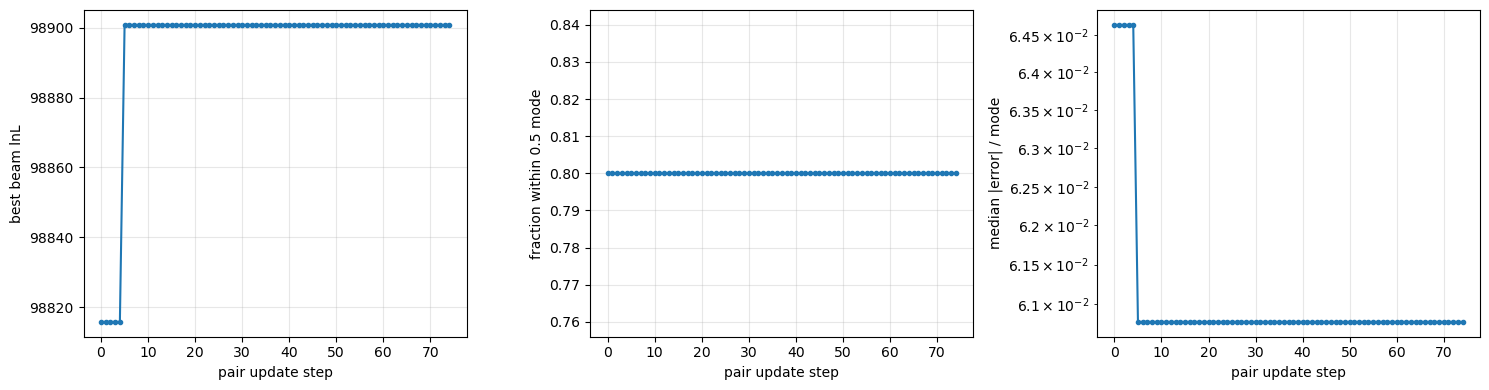

In [10]:
if "beam_history_df" in globals() and len(beam_history_df):
    best_h = beam_history_df[beam_history_df["rank"] == 0]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(best_h["step"], best_h["lnL"], ".-")
    axes[1].plot(best_h["step"], best_h["frac_within_half_mode"], ".-")
    axes[2].plot(best_h["step"], best_h["median_abs_modes"], ".-")
    axes[2].set_yscale("log")
    for ax in axes:
        ax.grid(alpha=0.3); ax.set_xlabel("pair update step")
    axes[0].set_ylabel("best beam lnL")
    axes[1].set_ylabel("fraction within 0.5 mode")
    axes[2].set_ylabel("median |error| / mode")
    plt.tight_layout()

    rows = []
    for rank, st in enumerate(beam_states):
        rows.append(dict(rank=rank, lnL=st["lnL"], **recovery_score(st["distances"])))
    display(pd.DataFrame(rows))
    display(best_h.tail(20))
else:
    print("Run beam optimizer first.")

## Which Pulsars Are Stuck?

Use this after beam optimizer to identify which pulsars remain in wrong modes and whether any lower-rank beam state fixes them.

In [11]:
if "beam_states" in globals() and beam_states:
    rows=[]
    for rank, st in enumerate(beam_states):
        err_modes = (st["distances"] - truth_dist) / mode_spacings
        for i, psr in enumerate(disco_psrs):
            rows.append(dict(rank=rank, label=st.get("label", ""), pulsar=psr.name, pulsar_index=i, err_modes=err_modes[i], abs_err_modes=abs(err_modes[i]), lnL=st["lnL"]))
    stuck_df = pd.DataFrame(rows)
    display(stuck_df.pivot_table(index=["pulsar_index", "pulsar"], columns="rank", values="abs_err_modes").round(3))
    display(stuck_df.groupby(["pulsar_index", "pulsar"]).agg(best_abs_err_modes=("abs_err_modes", "min"), best_rank=("abs_err_modes", "idxmin")).reset_index())
else:
    print("Run beam optimizer first.")


,rank,0,1,2,3,4,5,6,7,8,9,10,11
pulsar_index,pulsar,,,,,,,,,,,,
0,J0437-4715,0.047,0.047,0.047,0.047,0.074,0.074,0.074,0.074,0.074,0.047,0.074,0.047
1,J0030+0451,0.111,0.111,0.111,0.111,36.352,36.352,36.352,36.352,0.111,0.111,36.352,18.106
2,J1744-1134,0.045,0.045,0.045,0.045,21.699,21.699,21.699,21.699,21.540,21.699,21.699,21.699
3,J1909-3744,20.117,20.117,20.117,20.117,20.111,20.111,20.111,20.111,20.111,20.111,20.111,20.111
4,J1022+1001,0.023,0.023,0.023,0.023,65.433,65.433,65.433,65.433,65.433,79.219,65.433,65.433
5,J1713+0747,0.064,0.064,0.064,0.064,52.761,52.761,67.587,52.761,67.587,0.064,120.070,0.064
6,J0711-6830,0.072,0.072,0.072,0.072,159.549,159.549,159.549,159.549,159.549,159.549,12.571,159.549
7,J1012+5307,0.058,0.058,0.058,0.058,147.431,147.431,147.431,147.431,147.431,55.303,147.431,55.303
8,J1730-2304,0.065,0.065,0.065,0.065,98.277,98.277,98.277,98.277,98.277,98.277,98.277,26.544


,pulsar_index,pulsar,best_abs_err_modes,best_rank
0,0,J0437-4715,0.047478,0
1,1,J0030+0451,0.110704,1
2,2,J1744-1134,0.045347,2
3,3,J1909-3744,20.111494,83
4,4,J1022+1001,0.022563,4
5,5,J1713+0747,0.063932,5
6,6,J0711-6830,0.072441,6
7,7,J1012+5307,0.057614,7
8,8,J1730-2304,0.065333,8
9,9,J2145-0750,0.077523,89


In [12]:
def surface_truth_diagnostics(rec):
    scan = rec.get("scan")
    if scan is None:
        return None
    gi, gj, z = np.asarray(scan["grid_i"]), np.asarray(scan["grid_j"]), np.asarray(scan["lnL"])
    ii, ti = nearest_grid_value(gi, rec["truth_i"])
    jj, tj = nearest_grid_value(gj, rec["truth_j"])
    pk = np.unravel_index(np.nanargmax(z), z.shape)
    return dict(
        step=rec["step"], sweep=rec["sweep"], pair_index=rec["pair_index"], pair=f"{rec['psr_i']} / {rec['psr_j']}",
        truth_i_in_grid=bool(np.isclose(ti, rec["truth_i"], rtol=0, atol=1e-14)),
        truth_j_in_grid=bool(np.isclose(tj, rec["truth_j"], rtol=0, atol=1e-14)),
        peak_i=float(gi[pk[0]]), peak_j=float(gj[pk[1]]),
        lnL_at_truth=float(z[ii, jj]), lnL_peak=float(z[pk]),
        delta_lnL_truth_minus_peak=float(z[ii, jj] - z[pk]),
    )

if "beam_pair_records" in globals() and beam_pair_records:
    with_scans = [r for r in beam_pair_records if r.get("scan") is not None]
    print(f"beam_pair_records={len(beam_pair_records)}, with scans={len(with_scans)}")
    if with_scans:
        surf_diag = pd.DataFrame([surface_truth_diagnostics(r) for r in with_scans])
        display(surf_diag)
        if len(surf_diag):
            print("truth in both grid fraction:", (surf_diag["truth_i_in_grid"] & surf_diag["truth_j_in_grid"]).mean())
            print("median ΔlnL truth-peak:", surf_diag["delta_lnL_truth_minus_peak"].median())
    else:
        print("No stored scan surfaces. This should now be rare because records fall back to best updated proposal scan.")
        if "beam_history_df" in globals() and len(beam_history_df):
            display(beam_history_df[beam_history_df["rank"] == 0].tail(10))
else:
    print("Run beam optimizer first.")

beam_pair_records=20, with scans=20


,step,sweep,pair_index,pair,truth_i_in_grid,truth_j_in_grid,peak_i,peak_j,lnL_at_truth,lnL_peak,delta_lnL_truth_minus_peak
0,55,1,17,J0437-4715 / J0751+1807,False,False,0.153461,1.204574,98900.830161,98900.830161,0.000000
1,56,1,18,J0437-4715 / J1045-4509,False,False,0.153461,0.435144,98900.830161,98900.830161,0.000000
2,57,1,19,J0030+0451 / J1744-1134,False,False,0.334108,0.405977,98900.830161,98900.830161,0.000000
3,58,1,20,J1744-1134 / J1909-3744,False,False,0.405977,1.168241,-49877.592627,98900.830161,-148778.422787
4,59,1,21,J1909-3744 / J1022+1001,False,False,1.168241,0.704580,-49877.592627,98900.830161,-148778.422787
5,60,1,22,J1022+1001 / J1713+0747,False,False,0.704580,1.123891,98900.830161,98900.830161,0.000000
6,61,1,23,J1713+0747 / J0711-6830,False,False,1.123891,0.077030,98900.830161,98900.830161,0.000000
7,62,1,24,J0711-6830 / J1012+5307,False,False,0.077030,0.876307,98900.830161,98900.830161,0.000000
8,63,1,25,J1012+5307 / J1730-2304,False,False,0.876307,0.536900,98900.830161,98900.830161,0.000000
9,64,1,26,J1730-2304 / J2145-0750,False,False,0.536900,0.683639,36344.682942,98900.830161,-62556.147218


truth in both grid fraction: 0.0
median ΔlnL truth-peak: 0.0


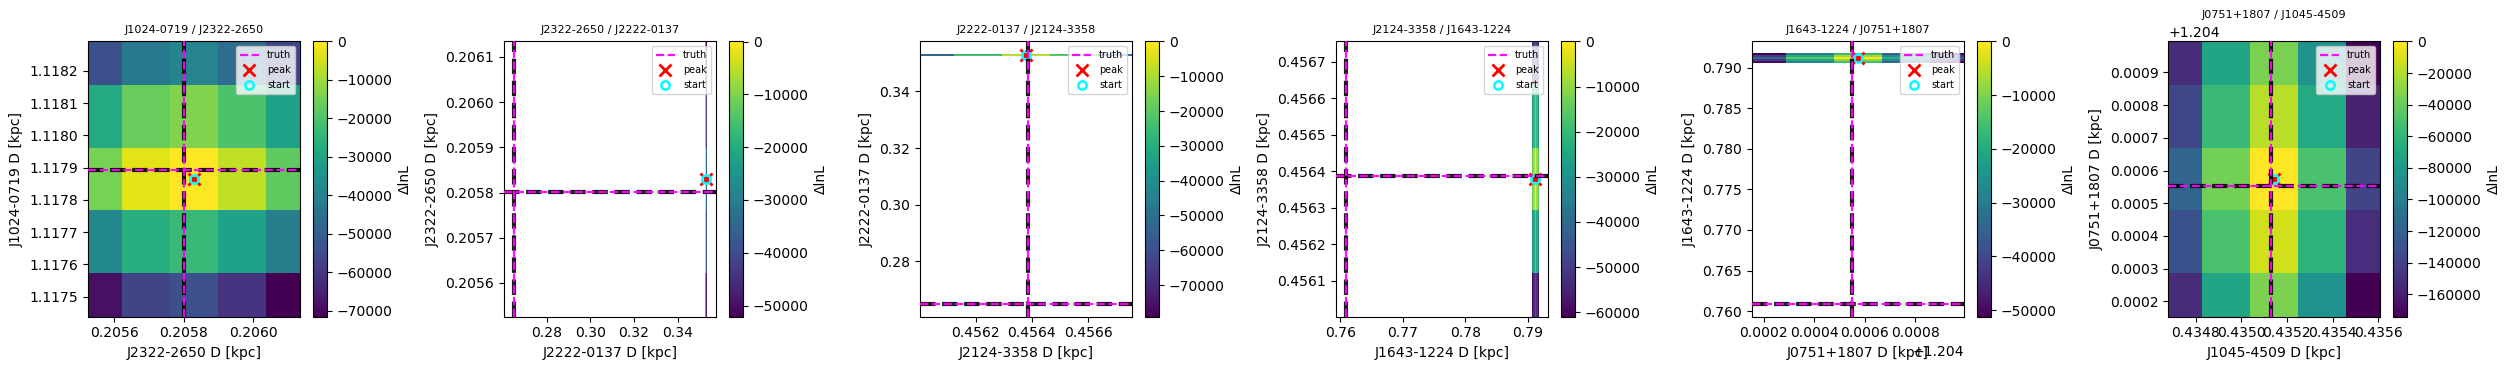

In [13]:
if "beam_pair_records" in globals() and beam_pair_records:
    records = [r for r in beam_pair_records if r.get("scan") is not None]
    if not records:
        print("No stored pair scans to plot. Best beam state may have remained unchanged for recorded pairs.")
        print("Try inspecting Beam Diagnostics table, or increase KEEP_PAIR_RECORDS / rerun with a shorter optimizer.")
    else:
        n = min(len(records), 6)
        fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.8), squeeze=False)
        for ax, rec in zip(axes[0], records[-n:]):
            scan = rec["scan"]
            z = scan["lnL"] - np.nanmax(scan["lnL"])
            im = ax.pcolormesh(scan["grid_j"], scan["grid_i"], z, shading="auto", cmap="viridis")
            draw_truth_crosshair(ax, rec["truth_i"], rec["truth_j"])
            ax.plot(scan["peak_j"], scan["peak_i"], "rx", ms=8, mew=2, label="peak")
            if "start_i" in scan and "start_j" in scan:
                ax.plot(scan["start_j"], scan["start_i"], "o", ms=6, mfc="none", mec="cyan", mew=1.8, label="start")
            set_pair_plot_limits(ax, scan["grid_i"], scan["grid_j"], rec["truth_i"], rec["truth_j"])
            ax.set_title(f"{rec['psr_i']} / {rec['psr_j']}", fontsize=8)
            ax.set_xlabel(f"{rec['psr_j']} D [kpc]")
            ax.set_ylabel(f"{rec['psr_i']} D [kpc]")
            ax.legend(fontsize=7)
            cb = plt.colorbar(im, ax=ax); cb.set_label("ΔlnL")
        plt.tight_layout()
else:
    print("Run beam optimizer first.")

## Critical Slice Test

This compares same pair grid conditioned on best beam vs full truth vector. If truth only peaks in the full-truth slice, optimizer is stuck globally. If truth does not peak even in full-truth slice in pure/noise-free mode, investigate signal model.

conditioned on best beam
  peak: 1.2045514508637556 0.43513057164121294 99361.22422358076
  truth: 1.2045514508637556 0.43513057164121294 99361.22422358076
  ΔlnL truth-peak: 0.0
conditioned on full truth
  peak: 1.2045514508637556 0.43513057164121294 105246.35240827108
  truth: 1.2045514508637556 0.43513057164121294 105246.35240827108
  ΔlnL truth-peak: 0.0


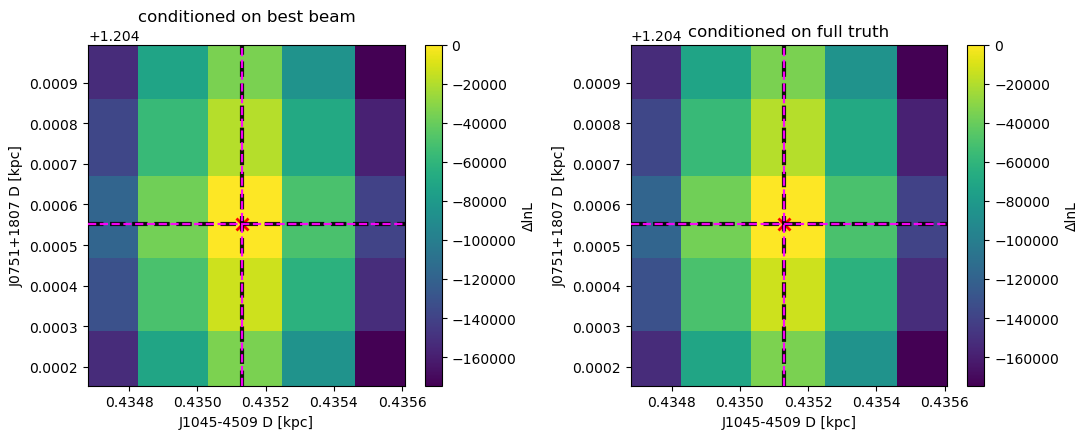

In [14]:
COMPARE_PAIR_RECORD_INDEX = -1

if "beam_pair_records" in globals() and beam_pair_records and "beam_states" in globals() and beam_states:
    records = [r for r in beam_pair_records if r.get("scan") is not None]
    if not records:
        print("No stored pair scans for critical slice test.")
    else:
        rec = records[COMPARE_PAIR_RECORD_INDEX]
        i, j = rec["i"], rec["j"]
        psr_i, psr_j = disco_psrs[i], disco_psrs[j]
        grid_i = np.unique(np.r_[rec["scan"]["grid_i"], truth_dist[i]])
        grid_j = np.unique(np.r_[rec["scan"]["grid_j"], truth_dist[j]])

        _, _, surf_best = scan_pulsar_pair_2d(logl_fn, beam_states[0]["values"], param_keys, distance_key(psr_i), distance_key(psr_j), grid_i, grid_j, chunk_size=CHUNK_SIZE, n_components=COMPONENTS)
        _, _, surf_truth = scan_pulsar_pair_2d(logl_fn, truth_values, param_keys, distance_key(psr_i), distance_key(psr_j), grid_i, grid_j, chunk_size=CHUNK_SIZE, n_components=COMPONENTS)

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), squeeze=False)
        for ax, surf, title in zip(axes[0], [surf_best, surf_truth], ["conditioned on best beam", "conditioned on full truth"]):
            z = surf - np.nanmax(surf)
            ii, _ = nearest_grid_value(grid_i, truth_dist[i])
            jj, _ = nearest_grid_value(grid_j, truth_dist[j])
            pk = np.unravel_index(np.nanargmax(surf), surf.shape)
            print(title)
            print("  peak:", grid_i[pk[0]], grid_j[pk[1]], float(surf[pk]))
            print("  truth:", grid_i[ii], grid_j[jj], float(surf[ii, jj]))
            print("  ΔlnL truth-peak:", float(surf[ii, jj] - surf[pk]))
            im = ax.pcolormesh(grid_j, grid_i, z, shading="auto", cmap="viridis")
            draw_truth_crosshair(ax, truth_dist[i], truth_dist[j])
            ax.plot(grid_j[pk[1]], grid_i[pk[0]], "rx", ms=9, mew=2)
            set_pair_plot_limits(ax, grid_i, grid_j, truth_dist[i], truth_dist[j])
            ax.set_title(title)
            ax.set_xlabel(f"{psr_j.name} D [kpc]")
            ax.set_ylabel(f"{psr_i.name} D [kpc]")
            cb = plt.colorbar(im, ax=ax); cb.set_label("ΔlnL")
        plt.tight_layout()
else:
    print("Run beam optimizer first.")